DataSet: https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset

- Antônio Enrique Sousa Silva
- Kelvin Araújo Ferreira

In [149]:
!pip install shap
!pip install gradio

In [150]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Base de Dados Fictícia:

* Nome do Dataset: DadosSaude

### Colunas:
* ID_Paciente: Identificador único do paciente
* Idade: Idade do paciente
* Genero: Gênero do paciente (Masculino, Feminino, Outro)
* Pressao_Arterial: Pressão arterial média (mm Hg)
* Nivel_Colesterol: Nível de colesterol (mg/dL)
* IMC: Índice de Massa Corporal
* Diabetes: Diagnóstico de diabetes (Sim, Não)
* Fumante: Se o paciente é fumante (Sim, Não)
* Atividade_Fisica: Nível de atividade física semanal (em horas)
* Medicacao: Uso de medicação para pressão arterial (Sim, Não)

## Agenda:

* Introdução ao Seaborn:

    * Introdução à aprendizagem de máquina supervisionada.
    * Breve apresentação da biblioteca SHAP.
    * Comparação ao gradio.

Importação de Bibliotecas e Carregamento dos Dados:

In [151]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import shap
import gradio as gr


# Leitura dos dados
data = pd.read_csv('/content/drive/MyDrive/Ciência da Computação/Data Science - Projeto de Extensão/Módulo 3/DS-005 - Visualização de dados de interesse para área da saúde/Aula 03/healthcare-dataset-stroke-data.csv')

# Selecionando 250 primeiras e 250 últimas linhas
data_sample = pd.concat([data.head(300), data.tail(300)], ignore_index=True)


In [152]:
# Verificando os dado
data_sample.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [153]:
data_sample.smoking_status.value_counts()

,count
smoking_status,
never smoked,216
Unknown,161
formerly smoked,125
smokes,98


In [154]:
# Verificando os dado
data_sample.tail()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
595,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
596,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
597,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
598,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0
599,44679,Female,44.0,0,0,Yes,Govt_job,Urban,85.28,26.2,Unknown,0


In [155]:
data_sample.smoking_status.value_counts()

,count
smoking_status,
never smoked,216
Unknown,161
formerly smoked,125
smokes,98


In [156]:
# Remover linhas onde smoking_status é "Unknown"
data_sample = data_sample[data_sample['smoking_status'] != 'Unknown']

In [157]:
data_sample.info()

<class 'pandas.core.frame.DataFrame'>
Index: 439 entries, 0 to 598
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 439 non-null    int64  
 1   gender             439 non-null    object 
 2   age                439 non-null    float64
 3   hypertension       439 non-null    int64  
 4   heart_disease      439 non-null    int64  
 5   ever_married       439 non-null    object 
 6   work_type          439 non-null    object 
 7   Residence_type     439 non-null    object 
 8   avg_glucose_level  439 non-null    float64
 9   bmi                409 non-null    float64
 10  smoking_status     439 non-null    object 
 11  stroke             439 non-null    int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 44.6+ KB


* Observe que bmi possui alguns valores faltantes:

In [158]:
data_sample.info()

<class 'pandas.core.frame.DataFrame'>
Index: 439 entries, 0 to 598
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 439 non-null    int64  
 1   gender             439 non-null    object 
 2   age                439 non-null    float64
 3   hypertension       439 non-null    int64  
 4   heart_disease      439 non-null    int64  
 5   ever_married       439 non-null    object 
 6   work_type          439 non-null    object 
 7   Residence_type     439 non-null    object 
 8   avg_glucose_level  439 non-null    float64
 9   bmi                409 non-null    float64
 10  smoking_status     439 non-null    object 
 11  stroke             439 non-null    int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 44.6+ KB


In [159]:
# Realizar a interpolação na coluna bmi
#Este método de interpolação calcula novos valores baseados em uma linha reta entre os pontos conhecidos mais próximos
data_sample['bmi'] = data_sample['bmi'].interpolate()

<ipython-input-159-5b85bf8c4fc8>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_sample['bmi'] = data_sample['bmi'].interpolate()


In [160]:
data_sample.info()

<class 'pandas.core.frame.DataFrame'>
Index: 439 entries, 0 to 598
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 439 non-null    int64  
 1   gender             439 non-null    object 
 2   age                439 non-null    float64
 3   hypertension       439 non-null    int64  
 4   heart_disease      439 non-null    int64  
 5   ever_married       439 non-null    object 
 6   work_type          439 non-null    object 
 7   Residence_type     439 non-null    object 
 8   avg_glucose_level  439 non-null    float64
 9   bmi                439 non-null    float64
 10  smoking_status     439 non-null    object 
 11  stroke             439 non-null    int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 44.6+ KB


In [161]:
# Mapeamento para smoking_status
smoking_status_mapping = {
    'never smoked': 0,
    'formerly smoked': 1,
    'smokes': 2
}

gender_mapping = {
    'Female': 0,
    'Male': 1
}

ever_married_mapping = {
    'No': 0,
    'Yes': 1
}

work_type = {
    'Never_worked': 0,
    'Govt_job': 1,
    'Private': 2,
    'Self-employed': 3,
    'Children': 4
}

Residence_type_mapping = {
    'Rural': 0,
    'Urban': 1
}

# Aplicar o mapeamento
data_sample['smoking_status'] = data_sample['smoking_status'].map(smoking_status_mapping)
data_sample['gender'] = data_sample['gender'].map(gender_mapping)
data_sample['ever_married'] = data_sample['ever_married'].map(ever_married_mapping)
data_sample['work_type'] = data_sample['work_type'].map(work_type)
data_sample['Residence_type'] = data_sample['Residence_type'].map(Residence_type_mapping)

In [162]:
data_sample.dropna(inplace=True)

In [163]:
data_sample.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,1,67.0,0,1,1,2.0,1,228.69,36.60,1,1
1,51676,0,61.0,0,0,1,3.0,0,202.21,34.55,0,1
2,31112,1,80.0,0,1,1,2.0,0,105.92,32.50,0,1
3,60182,0,49.0,0,0,1,2.0,1,171.23,34.40,2,1
4,1665,0,79.0,1,0,1,3.0,0,174.12,24.00,0,1


In [164]:
# Separando características e rótulo
X = data_sample.drop(columns=['stroke', 'id'])
y = data_sample['stroke']

In [165]:
from sklearn.ensemble import RandomForestClassifier

In [166]:
# Dividindo os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)

clf.fit(X_train, y_train)

# Avaliando o modelo
y_pred = clf.predict(X_test)

In [167]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
print("Acurácia:", accuracy)

# Gerando o relatório de classificação
report = classification_report(y_test, y_pred)
print("Relatório de Classificação")
print(report)

Acurácia: 0.7471264367816092
Relatório de Classificação
              precision    recall  f1-score   support

           0       0.74      0.77      0.76        44
           1       0.76      0.72      0.74        43

    accuracy                           0.75        87
   macro avg       0.75      0.75      0.75        87
weighted avg       0.75      0.75      0.75        87



In [168]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc

%matplotlib inline

# Função para plotar a matriz de confusão
def plot_confusion_matrix(y_test, y_pred, target_names):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
    disp.plot(cmap=plt.cm.Blues)
    plt.title('Matriz de Confusão')
    plt.show()

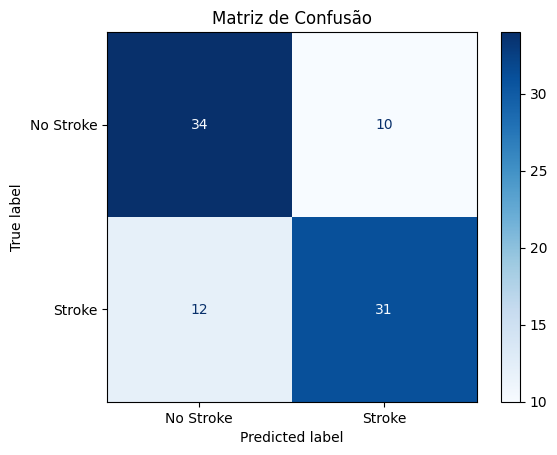

In [169]:
# Plotando a matriz de confusão
plot_confusion_matrix(y_test, y_pred, target_names=["No Stroke", "Stroke"])

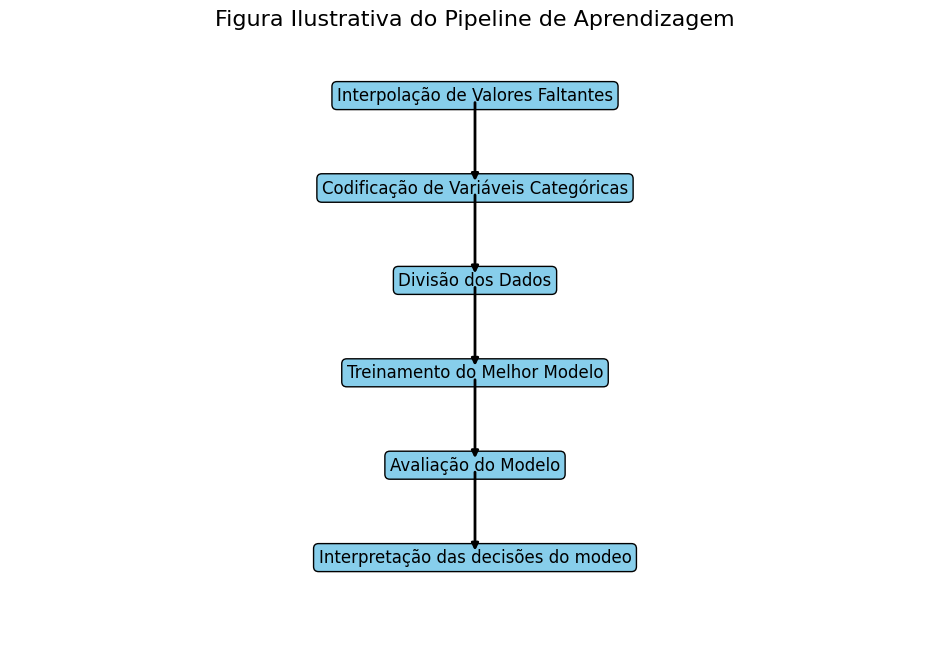

In [170]:
import matplotlib.pyplot as plt

def plot_pipeline():
    fig, ax = plt.subplots(figsize=(12, 8))

    # Lista de etapas do pipeline e suas posições
    steps = [
        ("Interpolação de Valores Faltantes", (0.5, 0.9)),
        ("Codificação de Variáveis Categóricas", (0.5, 0.75)),
        ("Divisão dos Dados", (0.5, 0.6)),
        ("Treinamento do Melhor Modelo", (0.5, 0.45)),
        ("Avaliação do Modelo", (0.5, 0.3)),
        ("Interpretação das decisões do modeo", (0.5, 0.15)),
    ]

    # Desenhar retângulos e texto para cada etapa
    for step, (x, y) in steps:
        ax.text(x, y, step, ha='center', va='center', fontsize=12, bbox=dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor="skyblue"))

    # Desenhar setas para conectar as etapas
    arrow_props = dict(facecolor='black', edgecolor='black', shrinkA=5, shrinkB=5, arrowstyle='-|>', lw=2)
    for i in range(len(steps) - 1):
        start = steps[i][1]
        end = steps[i + 1][1]
        ax.annotate('', xy=end, xytext=start, arrowprops=arrow_props)

    # Configurações finais do gráfico
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')  # Desliga os eixos

    plt.title("Figura Ilustrativa do Pipeline de Aprendizagem", fontsize=16)
    plt.show()

plot_pipeline()


In [171]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_breast_cancer
from shap import TreeExplainer, Explanation
from shap.plots import waterfall
import matplotlib.pyplot as plt

import shap
print(shap.__version__)

0.46.0


In [172]:
data_sample.drop(columns=['stroke', 'id']).columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status'],
      dtype='object')

In [173]:
df_train = pd.DataFrame(X_train, columns=data_sample.drop(columns=['stroke', 'id']).columns)
df_train['Rótulo'] = y_train

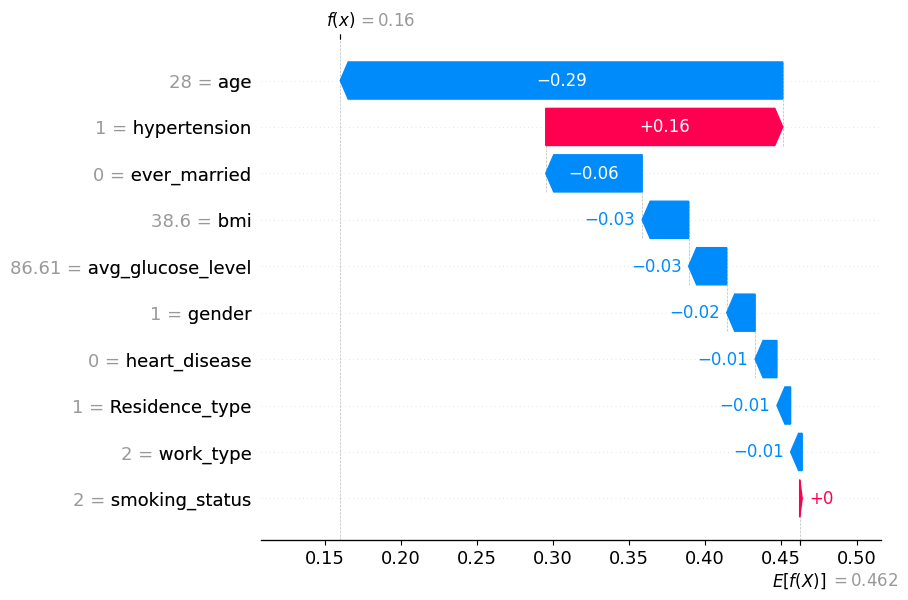

In [174]:
explainer = TreeExplainer(clf)
sv = explainer(X_train)
exp = Explanation(sv.values[:,:,1],
                  sv.base_values[:,1],
                  data=X_train,
                  feature_names= df_train.drop('Rótulo', axis=1).columns)
idx = 10
waterfall(exp[idx])

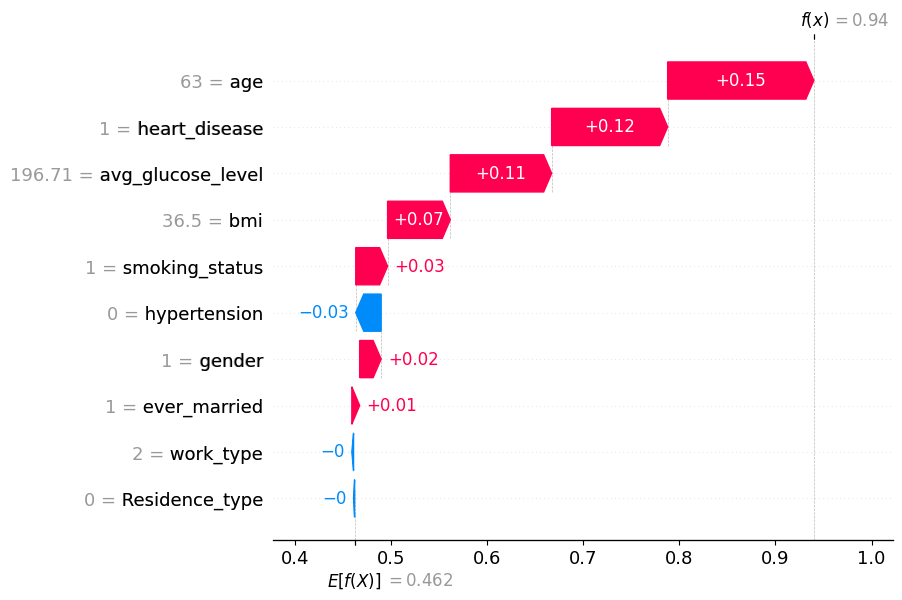

In [175]:
idx = 14
waterfall(exp[idx])

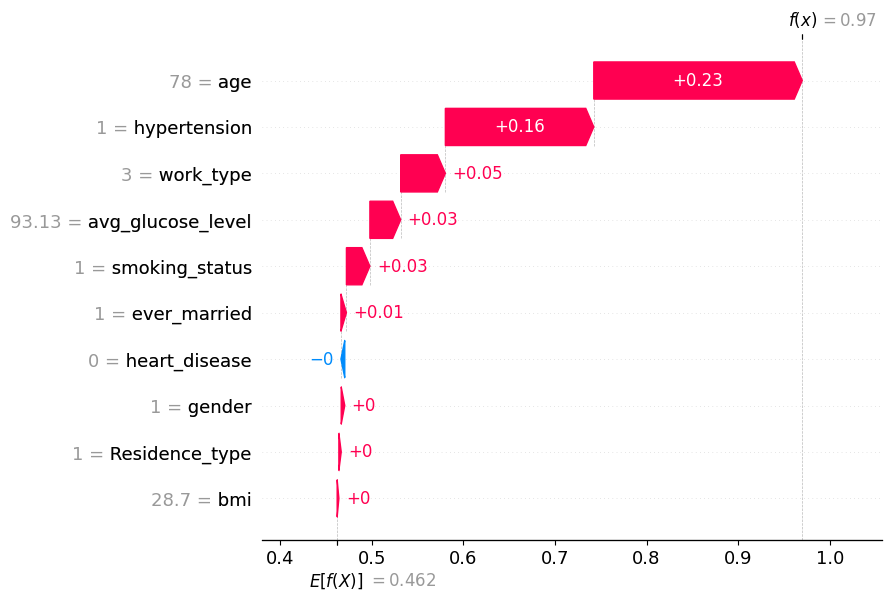

In [176]:
idx = -1
waterfall(exp[idx])

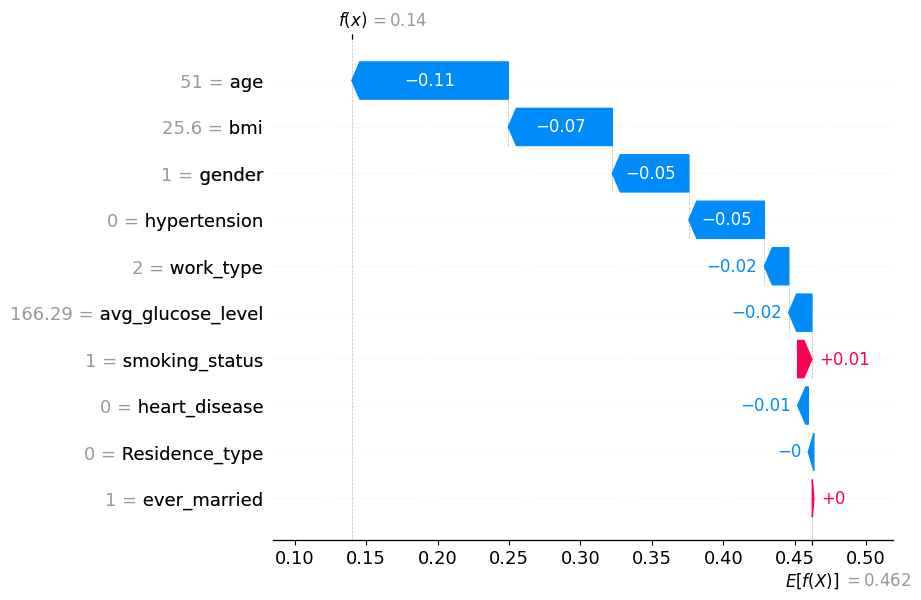

In [177]:
idx = -8
waterfall(exp[idx])

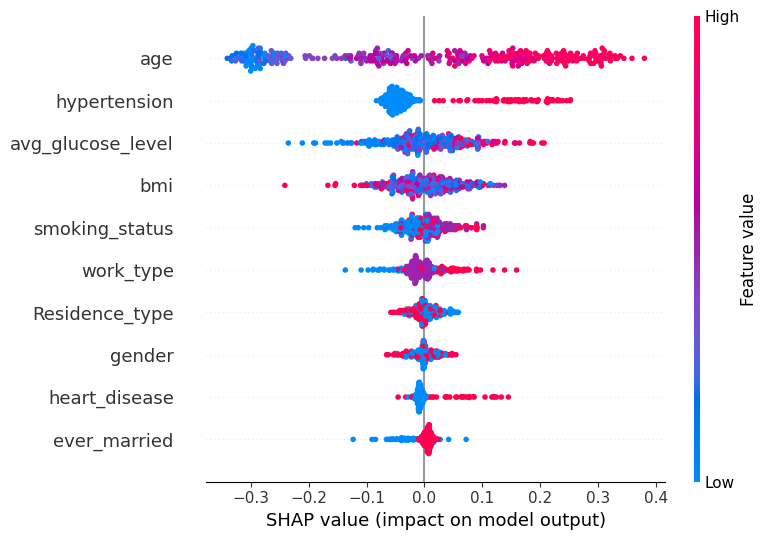

In [178]:
shap.summary_plot(sv.values[:,:,1], X_train, feature_names=df_train.drop('Rótulo', axis=1).columns)

## Gerando Recomendações

In [179]:
!pip install -q -U google-generativeai

In [180]:
import google.generativeai as genai

In [181]:
from google.colab import userdata

In [182]:
GOOGLE_API_KEY=userdata.get('GOOGLE_API_KEY')

genai.configure(api_key=GOOGLE_API_KEY)

In [183]:
model = genai.GenerativeModel('gemini-1.5-flash-latest')

In [184]:
data_sample.drop(columns=['stroke', 'id']).columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status'],
      dtype='object')

In [185]:
# Exemplo de função de recomendação (substitua pela sua lógica real)
def generate_recommendations(input_data, prediction_percentage):
    prompt_gemini = f"""
    #Tarefa
    Gerar recomendações para um paciente com base nos dados dele.

    Paciente com {prediction_percentage:.2f}% chance de ter um acidente cerebrovascular (AVC).
    Dados do paciente:
    Gênero: {'Feminino' if input_data[0][0] == 0 else 'Masculino'}
    Idade: {input_data[0][1]}
    Hipertensão: {'Sim' if input_data[0][2] else 'Não'}
    Doença Cardíaca: {'Sim' if input_data[0][3] else 'Não'}
    Já Casado: {'Sim' if input_data[0][4] else 'Não'}
    Tipo de Trabalho: {'Crianças' if input_data[0][5] == 0 else 'Emprego Governamental' if input_data[0][5] == 1 else 'Nunca Trabalhou' if input_data[0][5] == 2 else 'Privado' if input_data[0][5] == 3 else 'Autônomo'}
    Tipo de Residência: {'Rural' if input_data[0][6] == 0 else 'Urbano'}
    Nível Médio de Glicose: {input_data[0][7]}
    IMC: {input_data[0][8]}
    Status de Fumante: {'Nunca Fumou' if input_data[0][9] == 0 else 'Ex-fumante' if input_data[0][9] == 1 else 'Fumante' if input_data[0][9] == 2 else 'Desconhecido'}
    """
    '''
    if prediction_percentage >= 50:
        return "Recomendação: Consulte um médico urgentemente para uma avaliação detalhada.."
    else:
        return "Recomendação: Continue monitorando sua saúde regularmente."
    '''

    print(prompt_gemini)

    response = model.generate_content(prompt_gemini,
                                  generation_config=genai.types.GenerationConfig(
                                    candidate_count=1,
                                    temperature=0.5)
                                  )
    return response.text

In [186]:
# Função de predição e recomendação
def predict_and_recommend(gender, age, hypertension, heart_disease, ever_married, work_type, Residence_type, avg_glucose_level, bmi, smoking_status):
    # Mapeamento das variáveis categóricas
    gender_mapping = {'Female': 0, 'Male': 1}
    ever_married_mapping = {'No': 0, 'Yes': 1}
    work_type_mapping = {'Never_worked': 0, 'Govt_job': 1, 'Private': 2, 'Self-employed': 3, 'Children': 4}
    Residence_type_mapping = {'Rural': 0, 'Urban': 1}
    smoking_status_mapping = {'never smoked': 0, 'formerly smoked': 1, 'smokes': 2}

    # Aplicar o mapeamento
    gender = gender_mapping.get(gender, 0)  # Default para Female se valor não mapeado
    ever_married = ever_married_mapping.get(ever_married, 0)  # Default para No se valor não mapeado
    work_type = work_type_mapping.get(work_type, 0)  # Default para Never_worked se valor não mapeado
    Residence_type = Residence_type_mapping.get(Residence_type, 0)  # Default para Rural se valor não mapeado
    smoking_status = smoking_status_mapping.get(smoking_status, 0)  # Default para never smoked se valor não mapeado

    # Construir vetor de entrada para predição
    input_data = [[gender, age, hypertension, heart_disease, ever_married, work_type, Residence_type, avg_glucose_level, bmi, smoking_status]]

    # Realizar predição
    prediction = clf.predict_proba(input_data)[:, 1]  # Probabilidade de AVC

    # Converter predição para porcentagem
    prediction_percentage = prediction[0] * 100

    # Gerar recomendações com base na predição (substitua esta função pela sua lógica de recomendação)
    recommendation = generate_recommendations(input_data, prediction_percentage)

    return f'{prediction_percentage:.2f}%', recommendation

In [187]:
# Interface Gradio
iface = gr.Interface(
    fn=predict_and_recommend,
    inputs=[
        gr.Radio(['Masculino', 'Feminino'], label='Gênero'),
        gr.Slider(0, 100, step=1, label='Idade'),
        gr.Checkbox(label='Hipertensão'),
        gr.Checkbox(label='Doença Cardíaca'),
        gr.Radio(['Não', 'Sim'], label='Já Casado'),
        gr.Dropdown(['Crianças', 'Emprego Governamental', 'Nunca Trabalhou', 'Privado', 'Autônomo'], label='Tipo de Trabalho'),
        gr.Radio(['Rural', 'Urbano'], label='Tipo de Residência'),
        gr.Slider(0, 300, step=0.1, label='Nível Médio de Glicose'),
        gr.Slider(0, 50, step=0.1, label='IMC'),
        gr.Dropdown(['Fumou', 'Nunca Fumou', 'Fuma', 'Desconhecido'], label='Status de Fumante')
    ],
    outputs=[
        gr.Textbox(label='Probabilidade de AVC'),
        gr.Textbox(label='Recomendações')
    ],
    title="Predição e Recomendações de AVC",
    description="Infere a probabilidade de AVC e obtenha recomendações com base nos dados do paciente."
)

iface.launch()

Setting queue=True in a Colab notebook requires sharing enabled. Setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Running on public URL: https://79dd248d581a9bbf28.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from Terminal to deploy to Spaces (https://huggingface.co/spaces)


In [188]:
# Interface Gradio
iface = gr.Interface(
    fn=predict_and_recommend,
    inputs=[
        gr.Radio(['Masculino', 'Feminino'], label='Gênero'),
        gr.Slider(0, 100, step=1, label='Idade'),
        gr.Checkbox(label='Hipertensão'),
        gr.Checkbox(label='Doença Cardíaca'),
        gr.Radio(['Não', 'Sim'], label='Já Casado'),
        gr.Dropdown(['Crianças', 'Emprego Governamental', 'Nunca Trabalhou', 'Privado', 'Autônomo'], label='Tipo de Trabalho'),
        gr.Radio(['Rural', 'Urbano'], label='Tipo de Residência'),
        gr.Slider(0, 300, step=0.1, label='Nível Médio de Glicose'),
        gr.Slider(0, 50, step=0.1, label='IMC'),
        gr.Dropdown(['Fumou', 'Nunca Fumou', 'Fuma', 'Desconhecido'], label='Status de Fumante')
    ],
    outputs=[
        gr.Textbox(label='Probabilidade de AVC'),
        gr.Textbox(label='Recomendações')
    ],
    title="Predição e Recomendações de AVC",
    description="Infere a probabilidade de AVC e obtenha recomendações com base nos dados do paciente."
)

iface.launch()

Setting queue=True in a Colab notebook requires sharing enabled. Setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Running on public URL: https://1bd06366e36f7724ef.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from Terminal to deploy to Spaces (https://huggingface.co/spaces)


## Atividade

1. Ajuste o código, gerando gráficos para novas instâncias no SHAP.
2. Alterando o prompt do Gemini para gerar recomendações diferentes.
3. Faça seu cadastro no Kaggle, busque uma base de dados relacionada à saúde e adapte o código desta aula na usa base de dados. Exemplo de base de dados que pode ser utilizada:
* https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset
* https://www.kaggle.com/datasets/jillanisofttech/brain-stroke-dataset
* https://www.kaggle.com/datasets/mazharkarimi/heart-disease-and-stroke-prevention
* https://www.kaggle.com/datasets/lirilkumaramal/heart-stroke
* https://www.kaggle.com/datasets/amirhashemi1999/diabities-prediction/code
* https://www.kaggle.com/datasets/mahmoudhassanmahmoud/diabites-dataset

In [189]:
import shap
import xgboost as xgb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [190]:
# Carregando o dataset
data = pd.read_csv('/content/drive/MyDrive/Ciência da Computação/Data Science - Projeto de Extensão/Módulo 3/DS-005 - Visualização de dados de interesse para área da saúde/Aula 03/healthcare-dataset-stroke-data.csv')

In [191]:
# Preprocessamento básico (excluindo linhas com valores ausentes)
data = data.dropna()  # Remove missing values

# Convertendo variáveis categóricas para numéricas
data = pd.get_dummies(data, drop_first=True)

# Separando as features e o target
X = data.drop(columns=['stroke'])  # Excluindo a coluna 'stroke'
y = data['stroke']  # Alvo é a ocorrência de AVC

# Dividindo os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [192]:
# Treinando um modelo simples (exemplo com XGBoost)
model = xgb.XGBClassifier(eval_metric='logloss')
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...)

In [193]:
# Verificando os tipos de dados em X_test
print(X_test.dtypes)  # Isso mostrará os tipos de dados de cada coluna

id                                  int64
age                               float64
hypertension                        int64
heart_disease                       int64
avg_glucose_level                 float64
bmi                               float64
gender_Male                          bool
gender_Other                         bool
ever_married_Yes                     bool
work_type_Never_worked               bool
work_type_Private                    bool
work_type_Self-employed              bool
work_type_children                   bool
Residence_type_Urban                 bool
smoking_status_formerly smoked       bool
smoking_status_never smoked          bool
smoking_status_smokes                bool
dtype: object


In [194]:
# Convertendo X_test para um array NumPy
X_test_np = X_test.values

In [195]:
# Selecionando algumas instâncias para os gráficos SHAP
X_sample = X_test_np[[20, 30, 40, 50]]

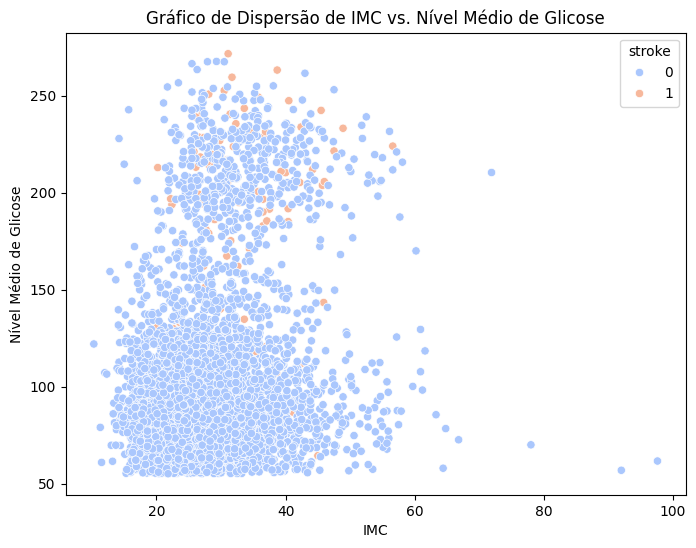

In [196]:
# Gráfico de dispersão para IMC vs. nível médio de glicose, colorido por ocorrência de AVC
plt.figure(figsize=(8, 6))
sns.scatterplot(x='bmi', y='avg_glucose_level', hue='stroke', data=data, palette='coolwarm')
plt.title('Gráfico de Dispersão de IMC vs. Nível Médio de Glicose')
plt.xlabel('IMC')
plt.ylabel('Nível Médio de Glicose')
plt.show()

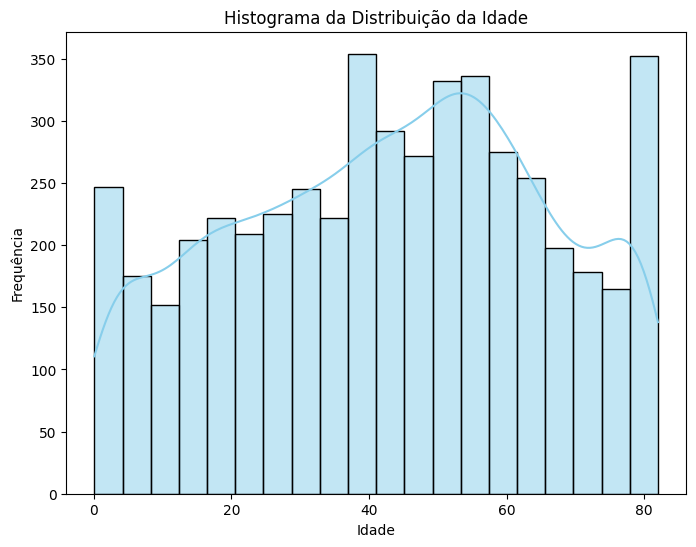

In [197]:
# Histograma para a distribuição da idade
plt.figure(figsize=(8, 6))
sns.histplot(data['age'], kde=True, color='skyblue')
plt.title('Histograma da Distribuição da Idade')
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.show()

<ipython-input-198-16b1b5aec358>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='stroke', y='age', data=data, palette='Set2')


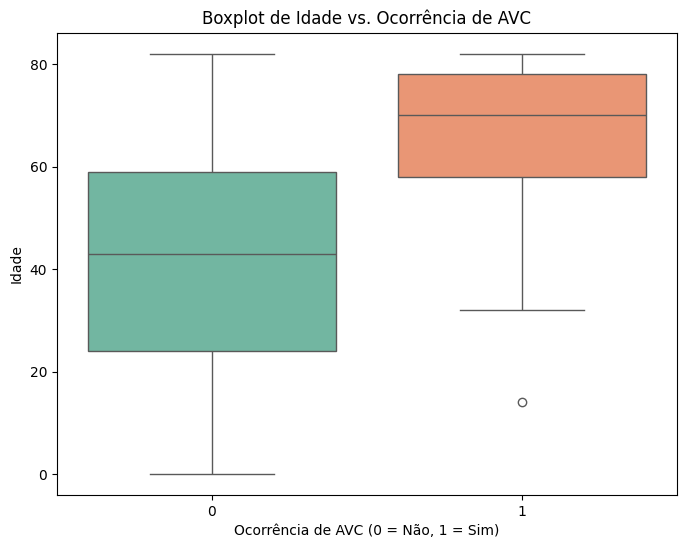

In [198]:
# Boxplot para idade vs. ocorrência de AVC
plt.figure(figsize=(8, 6))
sns.boxplot(x='stroke', y='age', data=data, palette='Set2')
plt.title('Boxplot de Idade vs. Ocorrência de AVC')
plt.xlabel('Ocorrência de AVC (0 = Não, 1 = Sim)')
plt.ylabel('Idade')
plt.show()